# Importing Libraries

In [35]:
import torch
import torchvision

In [36]:
from torchvision.transforms import transforms

In [37]:
from torch.utils.data import dataloader

In [38]:
import torch.nn as nn

# Define Transform

In [39]:
transformation_operation = transforms.Compose([transforms.ToTensor()])

# Downloading Data

In [40]:
train_dataset = torchvision.datasets.MNIST(root="./root", train=True, download=True, transform=transformation_operation)
val_dataset = torchvision.datasets.MNIST(root="./root", train=False, download=True, transform=transformation_operation)

# Defining Constants

In [52]:
num_classes = 10
batch_size = 64
num_channels = 1
img_size = 28
patch_size = 7
num_patches = (img_size // patch_size)**2
embedding_dim = 64
attention_heads = 4
transformer_blocks = 4
learning_rate = 0.001
epochs = 5
mlp_hidden_nodes = 128
epochs = 5

# Defining dataloaders

In [53]:
train_loader = dataloader.DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
val_loader = dataloader.DataLoader(val_dataset, batch_size = batch_size, shuffle = True)

# ViT Definitions

## Patch Embedding

In [54]:
class PatchEmbeddings(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embed = nn.Conv2d(num_channels, embedding_dim, kernel_size=patch_size, stride=patch_size)

  def forward(self, x):
    #patch_embedding
    x = self.patch_embed(x)
    #flattening
    x = x.flatten(2)
    #transpose
    x = x.transpose(1, 2)
    return x

## Transformer Encoder

In [62]:
class TransformerEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1 = nn.LayerNorm(embedding_dim)
    self.layer_norm2 = nn.LayerNorm(embedding_dim)
    self.multi_head_attention = nn.MultiheadAttention(embedding_dim, attention_heads, batch_first=True)
    self.mlp = nn.Sequential(
        nn.Linear(embedding_dim, mlp_hidden_nodes),
        nn.GELU(),
        nn.Linear(mlp_hidden_nodes, embedding_dim)
    )
  def forward(self, x):
    residual1 = x
    x = self.layer_norm1(x)
    x = self.multi_head_attention(x, x, x)[0]
    x = x + residual1

    residual2 = x
    x = self.layer_norm2(x)
    x = self.mlp(x)
    x = x + residual2

    return x

## MLP Head

In [63]:
class MLPHead(nn.Module):
  def __init__(self,):
    super().__init__()
    self.layer_norm1 = nn.LayerNorm(embedding_dim)
    self.mlp_head = nn.Sequential(
        nn.Linear(embedding_dim, num_classes),
    )

  def forward(self, x):
    x = self.layer_norm1(x)
    x = self.mlp_head(x)

    return x

## Class ViT

In [64]:
class VisionTransformer(nn.Module):
  def __init__(self):
    super().__init__()

    #imput block
    self.patch_embedding = PatchEmbeddings()
    #cls token
    self.cls_token = nn.Parameter(torch.randn(1, 1, embedding_dim))
    #position embedding
    self.position_embedding = nn.Parameter(torch.randn(1, num_patches + 1,embedding_dim))

    #transformer block
    self.transformer_blocks = nn.Sequential(
        *[TransformerEncoder() for _ in range(transformer_blocks)]
    )

    #mlp head
    self.mlp_head = MLPHead()

  def forward(self, x):

    #input block
    x = self.patch_embedding(x)
    B = x.size(0)
    class_tokens = self.cls_token.expand(B, -1, -1)
    x = torch.cat((class_tokens, x), dim = 1)
    x = x + self.position_embedding

    #transformer blocks
    x = self.transformer_blocks(x)

    #cls token in to mlp head
    x = x[:, 0]
    x = self.mlp_head(x)

    return x

## Example

In [65]:
data_points, labels = next(iter(train_loader))
print(data_points.shape)
patch_embed = nn.Conv2d(num_channels, embedding_dim, kernel_size=patch_size, stride=patch_size)
patch_embed_output = patch_embed(data_points)
print(patch_embed_output.shape)
patch_embed_output_flatten = patch_embed_output.flatten(2)
print(patch_embed_output_flatten.transpose(1,2).shape)

torch.Size([64, 1, 28, 28])
torch.Size([64, 64, 4, 4])
torch.Size([64, 16, 64])


# Training Code

In [66]:
from torch.optim import Adam
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VisionTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters() ,lr = learning_rate)
criterion = nn.CrossEntropyLoss()

In [67]:
for epoch in range(epochs):
    model.train()

    total_loss = 0.0
    correct_epoch = 0
    total_epoch = 0

    print(f"\nEpoch {epoch + 1}/{epochs}")

    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Metrics
        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct = (preds == labels).sum().item()
        accuracy = 100.0 * correct / labels.size(0)

        correct_epoch += correct
        total_epoch += labels.size(0)

        if batch_idx % 100 == 0:
            print(
                f"  Batch {batch_idx+1:3d}: "
                f"Loss = {loss.item():.4f}, "
                f"Accuracy = {accuracy:.2f}%"
            )

    epoch_acc = 100.0 * correct_epoch / total_epoch

    print(
        f"Epoch {epoch + 1} Summary: "
        f"Total Loss = {total_loss:.4f}, "
        f"Accuracy = {epoch_acc:.2f}%"
    )


Epoch 1/5
  Batch   1: Loss = 2.3976, Accuracy = 7.81%
  Batch 101: Loss = 0.5047, Accuracy = 84.38%
  Batch 201: Loss = 0.4022, Accuracy = 89.06%
  Batch 301: Loss = 0.3102, Accuracy = 90.62%
  Batch 401: Loss = 0.3435, Accuracy = 85.94%
  Batch 501: Loss = 0.1210, Accuracy = 96.88%
  Batch 601: Loss = 0.1302, Accuracy = 93.75%
  Batch 701: Loss = 0.2528, Accuracy = 95.31%
  Batch 801: Loss = 0.3673, Accuracy = 90.62%
  Batch 901: Loss = 0.0915, Accuracy = 95.31%
Epoch 1 Summary: Total Loss = 346.8408, Accuracy = 88.18%

Epoch 2/5
  Batch   1: Loss = 0.0187, Accuracy = 100.00%
  Batch 101: Loss = 0.1805, Accuracy = 95.31%
  Batch 201: Loss = 0.0793, Accuracy = 98.44%
  Batch 301: Loss = 0.3061, Accuracy = 90.62%
  Batch 401: Loss = 0.0526, Accuracy = 98.44%
  Batch 501: Loss = 0.1718, Accuracy = 92.19%
  Batch 601: Loss = 0.0810, Accuracy = 98.44%
  Batch 701: Loss = 0.1170, Accuracy = 96.88%
  Batch 801: Loss = 0.1486, Accuracy = 98.44%
  Batch 901: Loss = 0.1985, Accuracy = 92.19%


# Validation Accuracy

In [68]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = 100.0 * correct / total
print(f"Validation Accuracy: {test_acc:.2f}%")


Validation Accuracy: 98.02%


# Visualizing Images and Predictions

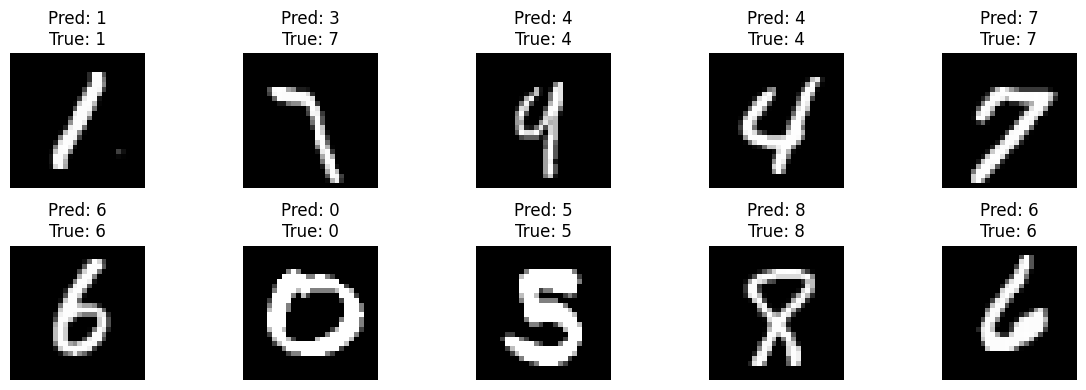

In [69]:
import matplotlib.pyplot as plt

# Get one batch from validation loader
model.eval()
images, labels = next(iter(val_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

# Move to CPU for plotting
images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

# Plot first 10 images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()
